---
## **Calculate and Examine the Protein Abundance Distributions for the Datasets**
Now that you have obtain a list of peptides that have been confidently matched to proteins of interest we need to process further to obtain estimates of the protein level abundances. \

## (III - 0) Imports and setup
Import some useful python packages for analyzing and plotting dataframes. 
Define the file path of the dataset you want and a label for the output files that are generated. 

In [106]:
import os, sys
import pandas as pd
import numpy as np
import requests
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from pyteomics import fasta

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

###########################################################################
## Define your root path as python notebooks require absolute paths to locate files
ROOT = os.path.abspath("../../")
print(f'Root path: {ROOT}')
###########################################################################


###########################################################################
## Define the path to the dataset
DATA = "data/Soybean_msstats.csv" ## Soybean dataset
DATA = os.path.join(ROOT, DATA)
print(f'Using dataset: {DATA}')

## Check that the dataset file exists
if not os.path.isfile(DATA):
    print(f'Error: {DATA} not found.')
    raise FileNotFoundError
else:
    print(f'FILE EXISTS: {DATA}')
###########################################################################


###########################################################################
## Choose a label to differentiate any output files that are generated
dataLABEL = "Soybean" 
print(f'Using label: {dataLABEL}')
###########################################################################


###########################################################################
## Download the fasta file for the Soybean proteome
fasta_path = os.path.join(ROOT, f"data/FASTA/{dataLABEL}.fasta")
print(f'Using FASTA file: {fasta_path}')

open(os.path.join(ROOT, f"data/FASTA/{dataLABEL}.fasta"), "wb").write(requests.get("https://rest.uniprot.org/uniprotkb/stream", params={"format":"fasta","query":"proteome:UP000008827","includeIsoform":"false"}).content)
if not os.path.isfile(fasta_path):
    print(f'Error: {fasta_path} not found.')
    raise FileNotFoundError
else:
    print(f'SAVED: {fasta_path}')
###########################################################################


###########################################################################
## Load the fasta data
fasta_obj = fasta.read(fasta_path)
fasta_dict = {entry[0].split('|')[1]: entry[1] for entry in fasta_obj}
print(f'Loaded {len(fasta_dict)} sequences from {fasta_path}')
print(f'Example entry: {list(fasta_dict.items())[0]}')
###########################################################################


###########################################################################
## Make output directory if it doesn't exist
output_dir = os.path.join(ROOT, f"data/{dataLABEL}_processed")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f'Created output directory: {output_dir}')
else:
    print(f'Output directory already exists: {output_dir}')
###########################################################################

Root path: /home/ians/git_repos/CURE2025_Comparative_massSpec
Using dataset: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_msstats.csv
FILE EXISTS: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_msstats.csv
Using label: Soybean
Using FASTA file: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/FASTA/Soybean.fasta
SAVED: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/FASTA/Soybean.fasta
Loaded 74858 sequences from /home/ians/git_repos/CURE2025_Comparative_massSpec/data/FASTA/Soybean.fasta
Example entry: ('A0A0R0H9T5', 'MPNPKVFFDMTIGGQPAGRIVMELYADVTPSTAENFRALCTGEKGAGRSGKPLHYKGSSFHRVIPNFMCQGGDFTAGNGTGGESIYGAKFADENFVKKHTGPGILSMANAGPGTNGSQFFICTTKTEWLDGKHVVFGQVVEGMDVVKEIEKVGSSSGRTAKPVVVADCGQLS')
Output directory already exists: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_processed


## (III - 1) Filter the proteins by coverage
*Explanation*: Filters out low-coverage proteins where less than 50% of their structure was observed. 
    
*Why*: Not all proteins are present in the cell at the same concentration. As with most spectroscopic measurements the signal observed in mass spectrometry proteomics experiments is roughly proportional to the population of the protein in the sample. Every instrument has a limit of detection where if the signal is too weak/strong it will no longer be recorded. Many proteins may fall near or below this threshold and thus have much greater uncertaintiy in their aquitition. As a simple filter we remove proteins whos sequences were not fully resolved. 
  
*Note*: The threshold choosen depends on how complex your sample is. If you are working with purified protein sample only containing a single protein, then you can choose a threshold of up to 95% for the coverage. But as your sample gets more complex and heterogeneous then the you need to relax the threshold as your signal gets more and more segmented and only parts of proteins are ever resolved with certainty. 


In [107]:
###########################################################################
## Load the data into a Pandas DataFrame and print the top 10 rows of the dataframe
df = pd.read_csv(DATA)
df = df[df["IsotopeLabelType"].isin(["H","L"])]
print(f'Loaded: {DATA}')
print(df.head())
###########################################################################


###########################################################################
## Map condition to HP or LP
condition = ["HP" if "HP" in c else "LP" for c in df["Condition"]]
df["Condition"] = condition
run = [c[-1] for c in df["Run"]]
df["Run"] = run
print(df.head())
df['ProteinName'] = [pn.split('|')[1] for pn in df['ProteinName']]
###########################################################################


###########################################################################
## Calculate coveragge for each protein and filter out low-coverage proteins
threshold = 0.25  # 50% coverage threshold
keep_df = []
for uniprot, name_df in df.groupby('ProteinName'):

    seq = []
    start_end = name_df[['Protein.Start', 'Protein.End']].values
    # print(start_end)
    for s, e in start_end:
        seq.append(np.arange(s, e+1))
    seq = np.hstack(seq).flatten()
    seq = np.unique(seq)
    seq.sort()
    # print(f'Unique peptide positions for {uniprot}:', seq)


    ref_seq = fasta_dict.get(uniprot, None)
    if ref_seq is None:
        print(f'No match found in FASTA file for {uniprot}')
        continue

    coverage = len(seq) / len(ref_seq) * 100
    # print(f'Coverage for {uniprot}: {coverage:.2f}%')
    if coverage >= threshold * 100:
        name_df['Coverage'] = coverage
        keep_df.append(name_df)
    # else:
    #     print(f'Excluding {uniprot} due to low coverage: {coverage:.2f}%')

if keep_df:
    keep_df = pd.concat(keep_df)
else:
    keep_df = pd.DataFrame()  # Return empty DataFrame if no proteins pass the filter
print(f'Filtered data to {len(keep_df)} rows after applying {threshold*100}% coverage threshold')
df = keep_df
print(df.head())
###########################################################################


Loaded: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_msstats.csv
                ProteinName PeptideSequence  Protein.Start  Protein.End  \
0  sp|A0A0R0H9T5|CYP2_SOYBN        FADENFVK             90           97   
1  sp|A0A0R0H9T5|CYP2_SOYBN        FADENFVK             90           97   
2  sp|A0A0R0H9T5|CYP2_SOYBN        FADENFVK             90           97   
3  sp|A0A0R0H9T5|CYP2_SOYBN        FADENFVK             90           97   
4  sp|A0A0R0H9T5|CYP2_SOYBN        FADENFVK             90           97   

   PrecursorCharge  FragmentIon  ProductCharge IsotopeLabelType  \
0                2          NaN            NaN                L   
1                2          NaN            NaN                L   
2                2          NaN            NaN                L   
3                2          NaN            NaN                L   
4                2          NaN            NaN                L   

                Condition  BioReplicate                     Ru

## (III - 2) Aggregate to protein-level per run and compute log₂ fold-change
*Explanation:*

* Collapses peptide intensities to **Protein × Run × Condition** by summing (`groupby(["ProteinName","Run","Condition"]).sum()`), then pivots to protein_sample_abundance format with one column per condition (e.g., `HP`, `LP`).
* Replaces non-finite values (±∞) with NaN and builds a quick QA table (`zero_counts_df`) that counts how many **zero** intensities each protein has in `HP` and `LP` across runs.
* Handles zeros via an **Limit of Detection (LOD) based imputation**: for any 0 in `HP`/`LP`, substitute a small random value drawn from a narrow Gaussian centered on a fixed **LOD** (here `500000`, with tiny jitter). This preserves rank order while avoiding division-by-zero and infinite ratios.
* Drops any rows that still have missing values or non-positive intensities after imputation.
* Computes per-run protein log change as `log2(HP / LP)` and appends it as `log2LP/HP`.

*Why:*
Summing to protein-level per run aligns with standard bottom-up quantification, reducing peptide-level noise and simplifying downstream stats. Pivoting creates paired condition columns for stable ratio calculations. LOD imputation prevents undefined ratios and overly-inflated fold-changes caused by zeros, yielding interpretable `log2` contrasts suitable for averaging across runs or statistical testing.

*Note:*  
The chosen LOD and jitter width influence variance and bias; a higher LOD shrinks ratios toward zero, while wider jitter inflates variance. The `zero_counts_df` is useful for QC plots (e.g., proteins frequently at LOD). If your study favors **missing-not-at-random** models or peptide-level mixed effects, replace this simple LOD approach with a method consistent with your missingness assumptions.


In [108]:
###########################################################################
# 2) Sum to Protein × Run × Label, then pivot to H/L
summ = (df.groupby(["ProteinName","Run","Condition"], as_index=False)["Intensity"].sum())
protein_sample_abundance = (summ.pivot(index=["ProteinName","Run"],
                   columns="Condition",
                   values="Intensity").reset_index())
###########################################################################


###########################################################################
# 3) Guard against zeros/Infs and compute log2(H/L)
protein_sample_abundance = protein_sample_abundance.replace([np.inf, -np.inf], np.nan)

## set the Limit of Detection (LOD) value and impute zeros 
LOD = 500000

HP_zeros_loc = np.where(protein_sample_abundance["HP"] == 0)[0]
gaussian = np.random.normal(loc=LOD, scale=0.3, size=len(HP_zeros_loc))
protein_sample_abundance.loc[HP_zeros_loc, "HP"] = gaussian

LP_zeros_loc = np.where(protein_sample_abundance["LP"] == 0)[0]
gaussian = np.random.normal(loc=LOD, scale=0.3, size=len(LP_zeros_loc))
protein_sample_abundance.loc[LP_zeros_loc, "LP"] = gaussian

protein_sample_abundance = protein_sample_abundance.dropna(subset=["HP","LP"])
protein_sample_abundance = protein_sample_abundance[(protein_sample_abundance["HP"] > 0) & (protein_sample_abundance["LP"] > 0)]
protein_sample_abundance["log2LP/HP"] = np.log2(protein_sample_abundance["LP"] / protein_sample_abundance["HP"])
print(protein_sample_abundance)
###########################################################################


###########################################################################
## Save the processed data to a CSV file
output_path = os.path.join(ROOT, f"data/{dataLABEL}_processed/{dataLABEL}_protein_abundance_data.csv")
protein_sample_abundance.to_csv(output_path, index=False)
print(f'Saved processed data to: {output_path}')
###########################################################################

Condition ProteinName Run            HP           LP  log2LP/HP
0          A0A0B5E2H5   1  8.371575e+08  730840238.5  -0.195943
1          A0A0B5E2H5   2  6.262567e+08  926823724.1   0.565541
2          A0A0B5E2H5   3  7.055061e+08  972480274.0   0.463010
3          A0A0R0E6P5   1  7.172394e+08  892863439.5   0.315985
4          A0A0R0E6P5   2  7.388859e+08  239760716.7  -1.623756
...               ...  ..           ...          ...        ...
2515           Q9XHC6   2  1.951944e+08  423765206.1   1.118353
2516           Q9XHC6   3  1.932236e+08  495934429.8   1.359878
2517           Q9ZS21   1  3.217492e+08  121764966.0  -1.401838
2518           Q9ZS21   2  3.224293e+08  293382335.5  -0.136201
2519           Q9ZS21   3  2.812622e+08  299562925.0   0.090943

[2520 rows x 5 columns]
Saved processed data to: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_processed/Soybean_protein_abundance_data.csv


## (III - 3) Compute Sample Statistics and Make Box and Violin Plots of each Sample Separately
You should compute the following statistics for each sample:
1.	The estimated protein abundance mean
2.	The estimated protein abundance minimum and maximum
3.	The estimated protein abundance median
4.	The estimate protein abundance first and third quartiles
5.  The estimated protein abundance variance

In [109]:
import matplotlib.pyplot as plt
from scipy import stats
import textwrap


## Function to compute the stats for each sample column 
def compute_stats(series, label):
    series = series.astype(float)
    # print(f'series: {series}')
    # print(sorted(series.values))
    # print(np.where(series == 0))
    """Return a dict and dataframe of summary statistics for a 1D numeric pandas Series."""
    clean = series.dropna()
    if clean.empty:
        return {
            "count": 0,
            "mean": np.nan,
            "median": np.nan,
            "mode": [],
            "variance": np.nan,
            "quantiles": {}
        }
    # mode: use pandas.Series.mode() for compatibility
    mode_vals = clean.mode()
    if len(mode_vals) != 1:
        mode_vals = mode_vals[:1]
    # print(f'mode_vals: {mode_vals}')

    results = {
        "count": int(clean.size),
        "mean": float(clean.mean()),
        "median": float(clean.median()),
        "mode": [float(m) for m in mode_vals] if not mode_vals.empty else [],
        "variance": float(clean.var(ddof=1)),  # sample variance
        "quantiles": {
            "0.0": float(clean.quantile(0.0)),
            "0.25": float(clean.quantile(0.25)),
            "0.5": float(clean.quantile(0.5)),
            "0.75": float(clean.quantile(0.75)),
            "1.0": float(clean.quantile(1.0)),
        }
    }
    results_df = {"count": int(clean.size),
                  "mean": float(clean.mean()),
                  "median": float(clean.median()),
                  "mode": [float(m) for m in mode_vals] if not mode_vals.empty else [],
                  "variance": float(clean.var(ddof=1)),  # sample variance,
                  "Q0.0": float(clean.quantile(0.0)),
                  "Q0.25": float(clean.quantile(0.25)),
                  "Q0.5": float(clean.quantile(0.5)),
                  "Q0.75": float(clean.quantile(0.75)),
                  "Q1.0": float(clean.quantile(1.0))}
    results_df = pd.DataFrame(results_df)
    results_df['label'] = label
    results_df.insert(0, "label", results_df.pop("label"))
    return results_df, results
    
## Compute per-sample stats
stats_dict = {}
stats_dfs = []
for run, run_df in protein_sample_abundance.groupby('Run'):
    for col in ['HP', 'LP', 'log2LP/HP']:
        stats_df, stats_dict[f'{run}_{col}'] = compute_stats(run_df[col], f'{run}_{col}')
        stats_dfs.append(stats_df)
        
stats_df = pd.concat(stats_dfs)
# print as an interactive table
import IPython
IPython.display.display(IPython.display.HTML(stats_df.to_html()))
###########################################################################

,label,count,mean,median,mode,variance,Q0.0,Q0.25,Q0.5,Q0.75,Q1.0
0,1_HP,840,5.309737e+09,8.275674e+08,499999.806864,1.280716e+21,499999.806864,3.166718e+08,8.275674e+08,2.239567e+09,8.977407e+11
0,1_LP,840,6.026066e+09,8.045196e+08,499999.517882,1.860580e+21,499999.517882,2.786519e+08,8.045196e+08,2.357750e+09,1.067078e+12
0,1_log2LP/HP,840,-9.658261e-02,-9.998661e-02,-9.416019,1.794362e+00,-9.416019,-6.718079e-01,-9.998661e-02,3.884001e-01,5.886664e+00
0,2_HP,840,5.234495e+09,8.216877e+08,499999.914494,1.222604e+21,499999.914494,3.303074e+08,8.216877e+08,2.190431e+09,8.305862e+11
0,2_LP,840,5.770253e+09,8.087784e+08,499999.772836,1.247128e+21,499999.772836,2.806334e+08,8.087784e+08,2.326157e+09,7.765720e+11
0,2_log2LP/HP,840,-1.079992e-01,-6.495072e-02,-9.051204,1.974131e+00,-9.051204,-6.721715e-01,-6.495072e-02,3.921103e-01,1.371696e+01
0,3_HP,840,5.115352e+09,8.202577e+08,500000.038681,9.035277e+20,500000.038681,3.077229e+08,8.202577e+08,2.101032e+09,6.858348e+11
0,3_LP,840,6.211321e+09,7.938071e+08,499999.512464,2.100749e+21,499999.512464,2.912016e+08,7.938071e+08,2.466496e+09,1.165528e+12
0,3_log2LP/HP,840,-2.314331e-02,-3.963082e-02,-9.241099,2.099609e+00,-9.241099,-5.644067e-01,-3.963082e-02,4.173276e-01,1.125761e+01


### Make Box Plots and Violin plots of each Sample Separately

<class 'matplotlib.patches.PathPatch'>
<class 'matplotlib.patches.PathPatch'>
<class 'matplotlib.patches.PathPatch'>
<class 'matplotlib.patches.PathPatch'>
<class 'matplotlib.patches.PathPatch'>
<class 'matplotlib.patches.PathPatch'>


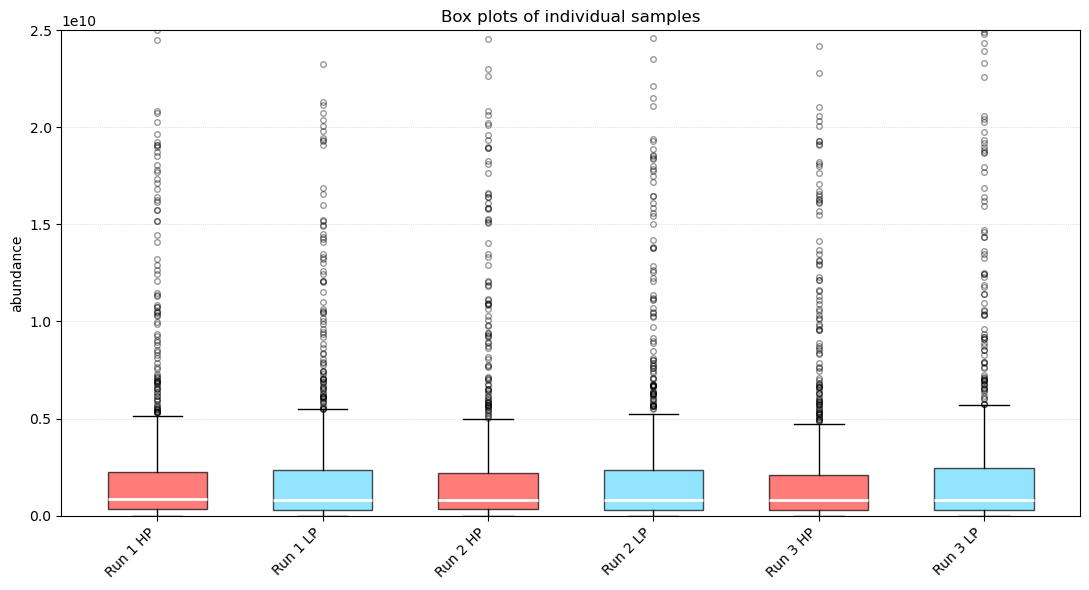

In [110]:
###########################################################################
"""
Box plots for individual samples with custom labels.

Parameters
----------
df : pd.DataFrame
    Protein abundance table (rows=proteins, cols=samples).
sample_cols : List[str]
    Columns in df to plot.
label_map : Dict[str,str]
    Mapping from sample column name to custom label for x-axis.
output_path : str or None
    If given, saves figure to this path.
log_scale : bool
    If True, plot log2(abundance + small pseudocount).
"""
log_scale = False

# Prepare data array for boxplot
data = []
labels = []
color = []
for run, run_df in protein_sample_abundance.groupby('Run'):
    for col in ['HP', 'LP']:
        series = run_df[col]
        if log_scale:
            series = np.log2(series.replace(0, np.nan) + 1e-6)
        data.append(series.dropna().values)
        labels.append(f'Run {run} {col}')
        # if col == 'HP' grey facecolor and if 'LP' light blue facecolor
        if col == 'HP':
            color.append("#ff4441")  # ruby red
        else:
            color.append("#66d9ff")  # navy blue


fig, ax = plt.subplots(figsize=(1.5 * len(labels) + 2, 6))
bp = ax.boxplot(data, patch_artist=True, widths=0.6, manage_ticks=False)

# Light styling: gray boxes with white medians
for i, box in enumerate(bp['boxes']):
    print(type(box))
    box.set(facecolor=color[i], alpha=0.7, edgecolor='black')
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1)
for cap in bp['caps']:
    cap.set(color='black', linewidth=1)
for median in bp['medians']:
    median.set(color='white', linewidth=2)
for flier in bp['fliers']:
    flier.set(marker='o', alpha=0.4, markersize=4)

ax.set_xticks(np.arange(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=45, ha='right')
ylabel = "log2(abundance)" if log_scale else "abundance"
ax.set_ylabel(ylabel)
ax.set_title("Box plots of individual samples")
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.7)
ax.set_ylim(-1e7, 2.5e10)
fig.tight_layout()
plt.show()




### Make Violin Plot of Protein Abundance

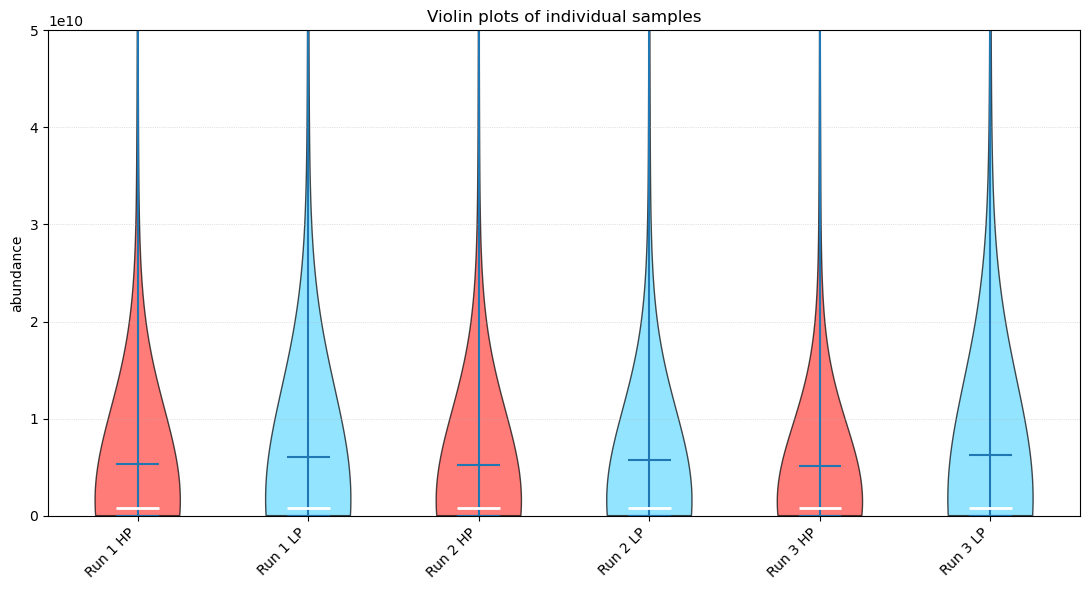

In [111]:
###########################################################################
"""
Violin plots for individual samples with custom labels.

Parameters
----------
df : pd.DataFrame
    Protein abundance table (rows=proteins, cols=samples).
sample_cols : List[str]
    Columns in df to plot.
label_map : Dict[str,str]
    Mapping from sample column name to custom label for x-axis.
output_path : str or None
    If given, saves figure to this path.
log_scale : bool
    If True, plot log2(abundance + small pseudocount).
"""
# Prepare data array for violin plot
data = []
labels = []
color = []
for run, run_df in protein_sample_abundance.groupby('Run'):
    for col in ['HP', 'LP']:
        series = run_df[col]
        if log_scale:
            series = np.log2(series.replace(0, np.nan) + 1e-6)
        data.append(series.dropna().values)
        labels.append(f'Run {run} {col}')
        # if col == 'HP' grey facecolor and if 'LP' light blue facecolor
        if col == 'HP':
            color.append("#ff4441")  # ruby red
        else:
            color.append("#66d9ff")  # navy blue

fig, ax = plt.subplots(figsize=(1.5 * len(labels) + 2, 6))
parts = ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True, points=10000)

# Light styling: gray violins with white medians
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(color[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)
if 'cmedians' in parts:
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

ax.set_xticks(np.arange(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=45, ha='right')
ylabel = "log2(abundance)" if log_scale else "abundance"
ax.set_ylabel(ylabel)
ax.set_title("Violin plots of individual samples")
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.7)
ax.set_ylim(-1e7, 5e10)
fig.tight_layout()
plt.show()
###########################################################################


## **Differential Protein Abundance Mass Spectrometry Data of Soybean Dataset**

## (IV - 1) Statistical testing (Welch’s t-test)
*Explanation:*

* Applies Welch’s t-test per protein, comparing the standardized TREATMENT vs CONTROL vectors.
  
*Why Welch’s test?*
It does not assume equal variance between groups, a prudent choice for biological data where heteroskedasticity is common.

*Note*: Point out that with only 3 replicates per group, degrees of freedom are low; encourage students to visualize variance and consider the effect of small sample size on power and false negatives.

*Note*: Welch’s t-test is generally powerful when sample sizes are modest and distributions are approximately symmetric; the Mann–Whitney test is robust to non-normality but tests for difference in distribution location in a different way. It’s good practice to examine data (e.g., via violin/box plots) to decide if assumptions are reasonable.

In [112]:
###########################################################################
## Perform t-tests for each protein across all runs
from scipy.stats import ttest_1samp
def ttest_stats(x):
    x = pd.Series(x).dropna()
    n = x.size
    mean = x.mean() if n else np.nan
    # standard error
    stderr = x.std(ddof=1) / np.sqrt(n) if n >= 2 else np.nan
    p = np.nan
    if n >= 2:
        _, p = ttest_1samp(x, 0.0)
    return pd.Series({"n_runs": n, "mean_log2LP/HP": mean, "stderr_log2LP/HP": stderr, "p_value": p})
###########################################################################

###########################################################################
# NOTE: the unstack() is the key change vs your output
res = (protein_sample_abundance.groupby("ProteinName")["log2LP/HP"]
          .apply(ttest_stats)
          .unstack())
print(res.head())
###########################################################################

             n_runs  mean_log2LP/HP  stderr_log2LP/HP   p_value
ProteinName                                                    
A0A0B5E2H5      3.0        0.277536          0.238583  0.364741
A0A0R0E6P5      3.0        0.101791          0.940530  0.923695
A0A0R0E907      3.0       -0.647940          0.867985  0.533194
A0A0R0E916      3.0       -0.713003          0.179378  0.057855
A0A0R0EAR0      3.0       -2.270452          0.246249  0.011560


## (IV - 2) Ranking and multiple testing correction
*Explanation*: Sorts proteins by raw significance (smallest p-value first) to prioritize candidates.  

* Apply Benjamini–Hochberg false discovery rate (FDR) correction to control the expected proportion of false discoveries among proteins.  
  
*Why*: Thousands of proteins may be tested; without correction, the number of false positives at p<0.05 would be unacceptably high. FDR balances discovery with error control.  
  
*Note*: There are different FDR correction methods that rely on different assumptions. You should always check that the assumptions are not violated in your dataset before application of any statistical method.   


In [113]:
###########################################################################
# Benjamini–Hochberg FDR
from scipy.stats import false_discovery_control
p = res["p_value"]
res["q_value"] = false_discovery_control(p.values)
print(res)

###########################################################################
## Save the processed data to a CSV file
output_path = os.path.join(ROOT, f"data/{dataLABEL}_processed/{dataLABEL}_protein_abundance_change_stats.csv")
res.to_csv(output_path, index=False)
print(f'Saved processed data to: {output_path}')
###########################################################################

             n_runs  mean_log2LP/HP  stderr_log2LP/HP   p_value   q_value
ProteinName                                                              
A0A0B5E2H5      3.0        0.277536          0.238583  0.364741  0.476923
A0A0R0E6P5      3.0        0.101791          0.940530  0.923695  0.945071
A0A0R0E907      3.0       -0.647940          0.867985  0.533194  0.632351
A0A0R0E916      3.0       -0.713003          0.179378  0.057855  0.134995
A0A0R0EAR0      3.0       -2.270452          0.246249  0.011560  0.055905
...             ...             ...               ...       ...       ...
Q9SDZ0          3.0        1.417746          0.098850  0.004826  0.037850
Q9SPB8          3.0       -0.227116          0.287998  0.512976  0.612074
Q9SWR5          3.0        0.319683          0.206708  0.262026  0.373929
Q9XHC6          3.0        1.246509          0.070113  0.003149  0.031867
Q9ZS21          3.0       -0.482365          0.464389  0.408036  0.515800

[840 rows x 5 columns]
Saved processe

### Extract significant proteins
**Explanation:**

* Filters proteins whose adjusted p-value is below 0.05, declaring them differentially abundant between LP and HP.
* Prints their UniProt accession IDs.

**Why:**
This yields a candidate list for biological interpretation: proteins whose standardized abundance differs beyond expected noise.

In [114]:
# select the significant proteins
significant_proteins = res[res['q_value'] < 0.05]
# sort by fold change
significant_proteins = significant_proteins.sort_values(by='mean_log2LP/HP', ascending=False).reset_index()

# make interactive table
import IPython
IPython.display.display(IPython.display.HTML(significant_proteins.to_html()))

###########################################################################
## Save the processed data to a CSV file
output_path = os.path.join(ROOT, f"data/{dataLABEL}_processed/{dataLABEL}_sig_protein_abundance_change_stats.csv")
significant_proteins.to_csv(output_path, index=False)
print(f'Saved processed data to: {output_path}')
###########################################################################

,ProteinName,n_runs,mean_log2LP/HP,stderr_log2LP/HP,p_value,q_value
0,Q9FQE8,3.0,6.122322,0.233939,0.001457,0.027830
1,C6T7T3,3.0,5.133683,0.347488,0.004550,0.037528
2,A0A0R0KIG7,3.0,4.361759,0.067459,0.000239,0.024394
3,I1JFJ9,3.0,4.214108,0.255042,0.003643,0.033999
4,I1LIL5,3.0,4.095475,0.130926,0.001020,0.024805
5,A0A0R0FFE9,3.0,4.073189,0.266690,0.004260,0.036844
6,P39657,3.0,3.529482,0.085051,0.000580,0.024394
7,I1LDY8,3.0,3.498722,0.149515,0.001821,0.027830
8,I1KNJ4,3.0,3.365366,0.083214,0.000611,0.024394
9,P10743,3.0,3.363980,0.095254,0.000801,0.024394


Saved processed data to: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_processed/Soybean_sig_protein_abundance_change_stats.csv


## (IV - 4) Volcano plots

A **volcano plot** is a scatter plot that simultaneously displays both **magnitude of change** and **statistical significance** for each protein (or peptide) when comparing two conditions. It’s a rapid visual filter to highlight candidates that are both substantially and confidently different.

### Axes:

* **X-axis:** Fold change (here, `Fold2AbundChange`). This is usually on a log2 scale (positive means higher in condition B, negative means higher in condition A). It reflects **effect size** — how much a protein’s abundance changes.
* **Y-axis:** $-\log_{10}(\text{p-value})$ from a statistical test (e.g., Welch’s t-test on replicate abundances). Higher values mean stronger statistical evidence against the null (i.e., more significant). Using the negative log makes small p-values (strong significance) appear at the top. You can also plot the adjusted p-value after accounting the multiple hypothesis testing effects. 

### What Each Point Represents:

Each point is a protein. Its horizontal position is how big the abundance change is, and its vertical position is how unlikely that change is due to random noise (after correcting for multiple comparisons).

### Coloring & Thresholds (as in your plot)

* **Horizontal line at adjusted p-value = 0.05:**
  Marks the significance cutoff. Points above this line are statistically significant (adj p-value < 0.05).

* **Vertical line at 0 fold change:**
  Separates proteins that increase (right) from those that decrease (left) between the two conditions.

* **Color scheme:**

  * **Bright red:** Significant *and* large change (|Fold2AbundChange| ≥ 1). These are high-confidence, high-effect candidates.
  * **Pink:** Significant but small change (|Fold2AbundChange| < 1). Statistically reliable but modest in magnitude—could be biologically meaningful if consistent across pathways.
  * **Black:** Not significant (adj p-value ≥ 0.05), regardless of fold change—these could be noise or underpowered.


Number of significant proteins (p < 0.05): 334
Number of significant proteins (q < 0.05): 153


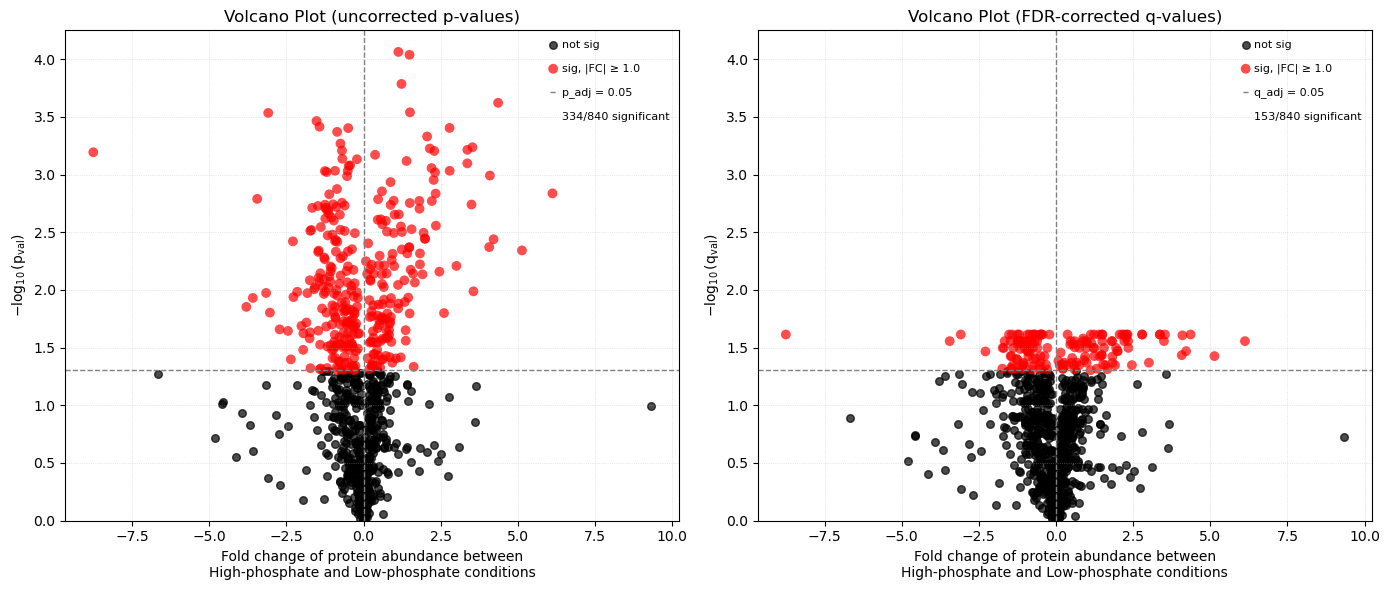

In [115]:
import matplotlib.patches as mpatches
signif_cutoff=0.05
fc_threshold=1.0
alpha=0.7
fc_col = 'mean_log2LP/HP'
pval_col = 'p_value'
qval_col = 'q_value'

# Prepare axes values for both p_value and q_value
x = res[fc_col].astype(float)
y_pval = -np.log10(res[pval_col].astype(float))
y_qval = -np.log10(res[qval_col].astype(float))

sig_pval = res[pval_col] < signif_cutoff
sig_qval = res[qval_col] < signif_cutoff
num_sig_pval = sig_pval.sum()
num_sig_qval = sig_qval.sum()
print(f'Number of significant proteins (p < {signif_cutoff}): {num_sig_pval}')
print(f'Number of significant proteins (q < {signif_cutoff}): {num_sig_qval}')
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Plot for p_value
ax = axes[0]
ax.scatter(x[~sig_pval], y_pval[~sig_pval], c="black", s=30, alpha=alpha, label="not sig")
ax.scatter(x[sig_pval], y_pval[sig_pval], c="red", edgecolor="none", s=50, alpha=alpha, label=f"sig, |FC| ≥ {fc_threshold}")
ax.axhline(-np.log10(signif_cutoff), linestyle="--", color="gray", linewidth=1, label=f"p_adj = {signif_cutoff}")
ax.axvline(0, linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("Fold change of protein abundance between\nHigh-phosphate and Low-phosphate conditions")
ax.set_ylabel(r"$-\log_{10}(\mathrm{p_{val}})$")
ax.set_title("Volcano Plot (uncorrected p-values)")
ax.set_ylim(0, 4.25)  # Adjust y-axis limit as needed
# Create legend handles for your annotation
annotation = mpatches.Patch(color='none', label=f'# significant = {num_sig_pval}/{len(res)}')
# Add annotation to legend
handles, labels = ax.get_legend_handles_labels()
handles.append(annotation)
labels.append(f'{num_sig_pval}/{len(res)} significant')
ax.legend(handles, labels, frameon=False, fontsize=8, handlelength=0.5, handletextpad=0.5, labelspacing=1.2)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
fig.tight_layout()

# Plot for q_value
ax = axes[1]
ax.scatter(x[~sig_qval], y_qval[~sig_qval], c="black", s=30, alpha=alpha, label="not sig")
ax.scatter(x[sig_qval], y_qval[sig_qval], c="red", edgecolor="none", s=50, alpha=alpha, label=f"sig, |FC| ≥ {fc_threshold}")
ax.axhline(-np.log10(signif_cutoff), linestyle="--", color="gray", linewidth=1, label=f"q_adj = {signif_cutoff}")
ax.axvline(0, linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("Fold change of protein abundance between\nHigh-phosphate and Low-phosphate conditions")
ax.set_ylabel(r"$-\log_{10}(\mathrm{q_{val}})$")
ax.set_title("Volcano Plot (FDR-corrected q-values)")
ax.set_ylim(0, 4.25)  # Adjust y-axis limit as needed
# Create legend handles for your annotation
annotation = mpatches.Patch(color='none', label=f'# significant = {num_sig_qval}/{len(res)}')
# Add annotation to legend
handles, labels = ax.get_legend_handles_labels()
handles.append(annotation)
labels.append(f'{num_sig_qval}/{len(res)} significant')
ax.legend(handles, labels, frameon=False, fontsize=8, handlelength=0.5, handletextpad=0.5, labelspacing=1.2)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
fig.tight_layout()
plt.show()

[1]: https://github.com/lazear/sage?utm_source=chatgpt.com "lazear/sage: Proteomics search & quantification so fast that ... - GitHub"
[2]: https://lazear.github.io/sage/?utm_source=chatgpt.com "Proteomics searching so fast it seems like Magic"
[3]: https://www.researchgate.net/publication/374639418_Sage_An_Open-Source_Tool_for_Fast_Proteomics_Searching_and_Quantification_at_Scale?utm_source=chatgpt.com "Sage: An Open-Source Tool for Fast Proteomics Searching and ..."
[4]: https://pubmed.ncbi.nlm.nih.gov/37819886/?utm_source=chatgpt.com "Sage: An Open-Source Tool for Fast Proteomics ... - PubMed"
[5]: https://www.sciencedirect.com/science/article/pii/S1535947624000884?utm_source=chatgpt.com "Rescoring Peptide Spectrum Matches: Boosting Proteomics ..."
[6]: https://pmc.ncbi.nlm.nih.gov/articles/PMC4125737/?utm_source=chatgpt.com "Conserved Peptide Fragmentation as a Benchmarking Tool for Mass ..."

## (IV - 5) Protein abundance distributions of the significant proteins



Number of significant proteins: 153
Example significant proteins: ['Q9FQE8', 'C6T7T3', 'A0A0R0KIG7', 'I1JFJ9', 'I1LIL5']
    ProteinName  n_runs  mean_log2LP/HP  stderr_log2LP/HP   p_value   q_value  \
0        Q9FQE8     3.0        6.122322          0.233939  0.001457  0.027830   
1        C6T7T3     3.0        5.133683          0.347488  0.004550  0.037528   
2    A0A0R0KIG7     3.0        4.361759          0.067459  0.000239  0.024394   
3        I1JFJ9     3.0        4.214108          0.255042  0.003643  0.033999   
4        I1LIL5     3.0        4.095475          0.130926  0.001020  0.024805   
..          ...     ...             ...               ...       ...       ...   
148      Q2PMQ0     3.0       -1.739885          0.159152  0.008264  0.048231   
149  A0A0R4J4J7     3.0       -2.287598          0.141349  0.003796  0.034215   
150      Q94IC4     3.0       -3.087195          0.052815  0.000293  0.024394   
151      I1KYC4     3.0       -3.445273          0.139110  0.001626  

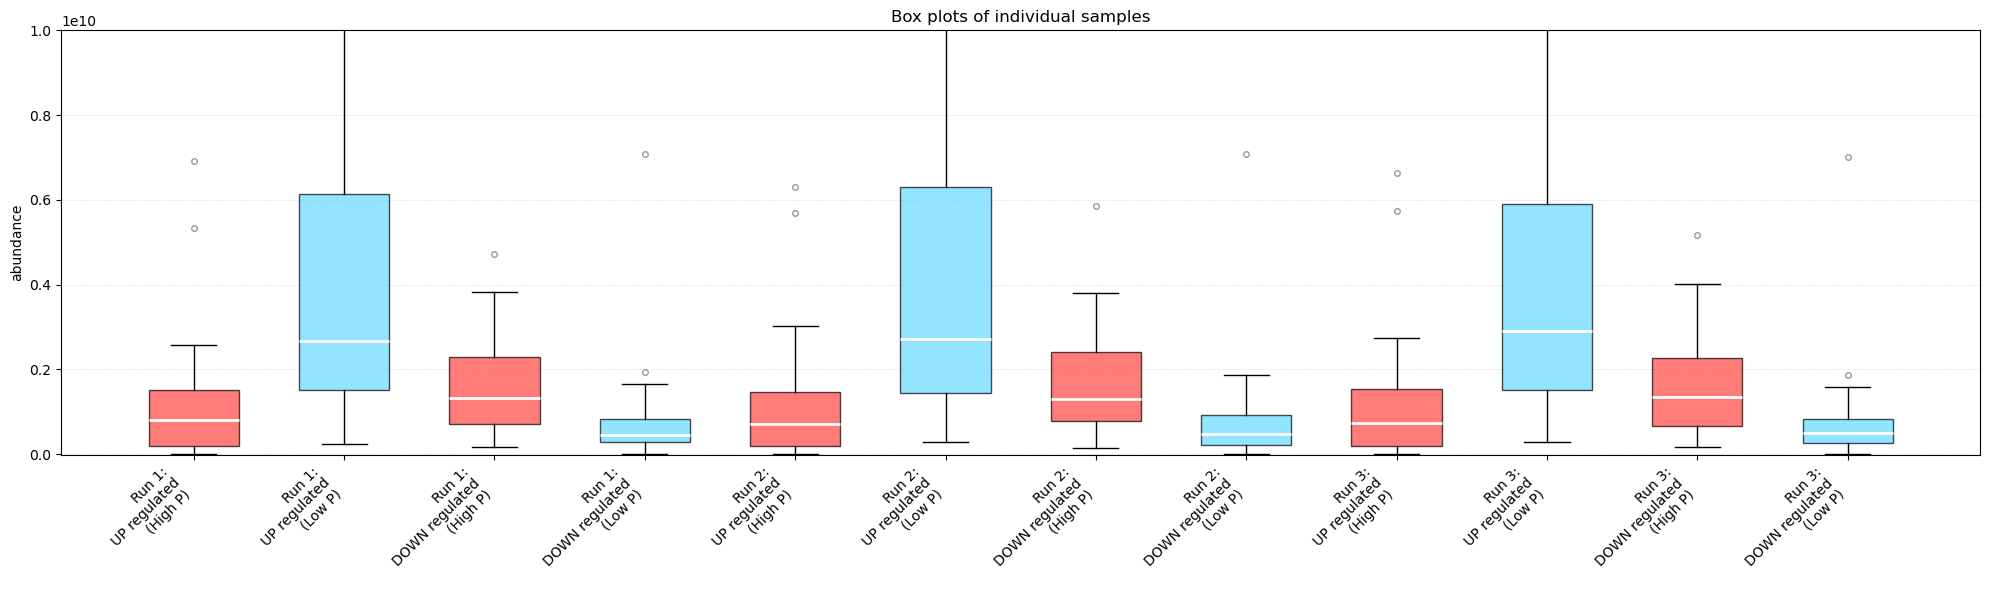

In [116]:
## first get the list of significant proteins uniprot IDs and subset the abundance dataframe for them
significant_protein_ids = significant_proteins['ProteinName'].tolist()
print(f'Number of significant proteins: {len(significant_protein_ids)}')
print(f'Example significant proteins: {significant_protein_ids[:5]}')
## tag each protein as up or down regulated
def tag_regulation(row, fc_col='mean_log2LP/HP', threshold=1.0):
    if row[fc_col] >= threshold:
        return 'up'
    elif row[fc_col] <= -threshold:
        return 'down'
    else:
        return 'no_change'

significant_proteins['regulation'] = significant_proteins.apply(tag_regulation, axis=1)
print(significant_proteins)

## get the number of up and down regulated proteins and their names
upregulated_proteins = significant_proteins[significant_proteins['regulation'] == 'up']
downregulated_proteins = significant_proteins[significant_proteins['regulation'] == 'down']
print(f'Number of upregulated proteins: {len(upregulated_proteins)}: {upregulated_proteins["ProteinName"].tolist()}')
print(f'Number of downregulated proteins: {len(downregulated_proteins)}: {downregulated_proteins["ProteinName"].tolist()}')

sig_protein_sample_abundance = protein_sample_abundance[protein_sample_abundance['ProteinName'].isin(significant_protein_ids)]
print(sig_protein_sample_abundance)
###########################################################################

###########################################################################
"""
Box plots for individual samples with custom labels.

Parameters
----------
df : pd.DataFrame
    Protein abundance table (rows=proteins, cols=samples).
sample_cols : List[str]
    Columns in df to plot.
label_map : Dict[str,str]
    Mapping from sample column name to custom label for x-axis.
output_path : str or None
    If given, saves figure to this path.
log_scale : bool
    If True, plot log2(abundance + small pseudocount).
"""
log_scale = False

# Prepare data array for boxplot
data = []
labels = []
color = []
for run, run_df in sig_protein_sample_abundance.groupby('Run'):
    print(run_df)

    # get the upregulated data
    up = run_df[run_df['ProteinName'].isin(upregulated_proteins['ProteinName'])]
    print(f'Run {run} upregulated proteins: {len(up)}')
    for col in ['HP', 'LP']:
        series = up[col]
        data.append(series.dropna().values)
        
        # if col == 'HP' grey facecolor and if 'LP' light blue facecolor
        if col == 'HP':
            labels.append(f'Run {run}:\nUP regulated\n(High P)')
            color.append("#ff4441")  # ruby red
        else:
            labels.append(f'Run {run}:\nUP regulated\n(Low P)')
            color.append("#66d9ff")  # navy blue

    down = run_df[run_df['ProteinName'].isin(downregulated_proteins['ProteinName'])]
    print(f'Run {run} downregulated proteins: {len(down)}')
    for col in ['HP', 'LP']:
        series = down[col]
        data.append(series.dropna().values)
        # if col == 'HP' grey facecolor and if 'LP' light blue facecolor
        if col == 'HP':
            labels.append(f'Run {run}:\nDOWN regulated\n(High P)')
            color.append("#ff4441")  # ruby red
        else:
            labels.append(f'Run {run}:\nDOWN regulated\n(Low P)')
            color.append("#66d9ff")  # navy blue    


fig, ax = plt.subplots(figsize=(1.5 * len(labels) + 2, 6))
bp = ax.boxplot(data, patch_artist=True, widths=0.6, manage_ticks=False)

# Light styling: gray boxes with white medians
for i, box in enumerate(bp['boxes']):
    print(type(box))
    box.set(facecolor=color[i], alpha=0.7, edgecolor='black')
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1)
for cap in bp['caps']:
    cap.set(color='black', linewidth=1)
for median in bp['medians']:
    median.set(color='white', linewidth=2)
for flier in bp['fliers']:
    flier.set(marker='o', alpha=0.4, markersize=4)

ax.set_xticks(np.arange(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=45, ha='right')
ylabel = "log2(abundance)" if log_scale else "abundance"
ax.set_ylabel(ylabel)
ax.set_title("Box plots of individual samples")
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.7)
ax.set_ylim(-1e7, 1e10)
fig.tight_layout()
plt.show()
###########################################################################
